In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [5]:
df = pd.read_csv('/kaggle/input/playground-series-s5e10/train.csv')

In [6]:
df

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [33]:
df_test = pd.read_csv('/kaggle/input/playground-series-s5e10/test.csv')

In [34]:
df_test

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
172580,690334,rural,2,0.01,45,dim,rainy,False,False,afternoon,True,True,2
172581,690335,rural,1,0.74,70,daylight,foggy,False,True,afternoon,False,False,2
172582,690336,urban,2,0.14,70,dim,clear,False,False,evening,True,True,1
172583,690337,urban,1,0.09,45,daylight,foggy,True,True,morning,False,True,0


In [35]:
df_test.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
dtype: int64

In [7]:
df['road_type'].value_counts()

road_type
highway    173672
rural      172719
urban      171363
Name: count, dtype: int64

In [8]:
df['weather'].value_counts()

weather
foggy    181463
clear    179306
rainy    156985
Name: count, dtype: int64

In [9]:
df['road_signs_present'].value_counts()

road_signs_present
False    259289
True     258465
Name: count, dtype: int64

In [10]:
df.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [11]:
df.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849974,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


In [12]:
df = df.drop('id', axis=1)

In [13]:
df

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


# use randomforest for calculating feature importance 

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [15]:
df_copy = df.copy()

In [16]:
df_copy

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [17]:
# Convert boolean columns to 0/1
df_copy['road_signs_present'] = df_copy['road_signs_present'].astype(int)
df_copy['public_road'] = df_copy['public_road'].astype(int)
df_copy['holiday'] = df_copy['holiday'].astype(int)
df_copy['school_season'] = df_copy['school_season'].astype(int)

# One-hot encode categorical columns
categorical_cols = ['road_type', 'lighting', 'weather', 'time_of_day']
df_copy = pd.get_dummies(df_copy, columns=categorical_cols, drop_first=True, dtype=int)

# Scale numerical columns
scaler = StandardScaler()
numerical_cols = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']
df_copy[numerical_cols] = scaler.fit_transform(df_copy[numerical_cols])

# Split features and target
X = df_copy.drop('accident_risk', axis=1)
y = df_copy['accident_risk']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
X_train

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning
143159,-0.438680,-0.215433,0.879591,0,0,1,1,0.906324,1,0,1,0,0,0,0,0
20172,1.346344,-1.132653,-1.337212,0,0,1,0,-0.209797,0,0,0,1,0,0,0,0
57926,-1.331192,-1.059275,1.512963,0,1,1,1,-0.209797,0,1,0,1,0,0,0,1
193319,0.453832,1.178740,0.879591,1,0,1,1,-0.209797,0,1,0,0,1,0,1,0
213938,0.453832,-0.215433,-0.703840,0,1,1,1,0.906324,1,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,1.346344,-1.609607,0.879591,0,1,1,0,-0.209797,1,0,1,0,0,0,0,1
365838,0.453832,-0.068678,1.512963,0,0,1,1,-0.209797,1,0,1,0,0,1,1,0
131932,0.453832,0.078077,1.512963,1,1,0,1,0.906324,0,0,0,1,0,0,0,0
146867,0.453832,1.545627,0.879591,1,0,0,0,3.138566,1,0,0,1,0,1,1,0


In [36]:
# Convert boolean columns to 0/1
df_test['road_signs_present'] = df_test['road_signs_present'].astype(int)
df_test['public_road'] = df_test['public_road'].astype(int)
df_test['holiday'] = df_test['holiday'].astype(int)
df_test['school_season'] = df_test['school_season'].astype(int)

# One-hot encode categorical columns
categorical_cols = ['road_type', 'lighting', 'weather', 'time_of_day']
df_test = pd.get_dummies(df_test, columns=categorical_cols, drop_first=True, dtype=int)

# Scale numerical columns
scaler = StandardScaler()
numerical_cols = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']
df_test[numerical_cols] = scaler.fit_transform(df_test[numerical_cols])

In [37]:
df_test

,id,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning
0,517754,-0.441450,-0.540727,-0.069852,1,1,1,1,-0.207387,0,0,0,1,0,0,0,0
1,517755,0.452089,-1.642283,-0.069852,1,0,1,0,-1.322018,0,1,1,0,1,0,0,0
2,517756,-0.441450,0.377236,-0.703284,1,0,1,1,-0.207387,0,1,1,0,0,0,0,0
3,517757,1.345629,1.699103,-0.703284,0,0,0,0,0.907243,1,0,0,0,0,1,0,0
4,517758,-0.441450,1.368636,-0.703284,1,0,0,1,2.021874,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172580,690334,-0.441450,-1.752439,-0.069852,0,0,1,1,0.907243,1,0,1,0,0,1,0,0
172581,690335,-1.334989,0.928014,1.513726,0,1,0,0,0.907243,1,0,0,0,1,0,0,0
172582,690336,-0.441450,-1.275098,1.513726,0,0,1,1,-0.207387,0,1,1,0,0,0,1,0
172583,690337,-1.334989,-1.458691,-0.069852,1,1,0,1,-1.322018,0,1,0,0,1,0,0,1


In [19]:
# Initialize and train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

# Display feature importance
print(feature_importance)

                   feature  importance
1                curvature    0.342509
11          lighting_night    0.238345
2              speed_limit    0.233270
7   num_reported_accidents    0.046271
12           weather_foggy    0.040433
13           weather_rainy    0.024959
0                num_lanes    0.015602
3       road_signs_present    0.007680
6            school_season    0.007618
4              public_road    0.007255
5                  holiday    0.006981
8          road_type_rural    0.006256
9          road_type_urban    0.006201
15     time_of_day_morning    0.006152
14     time_of_day_evening    0.006065
10            lighting_dim    0.004404


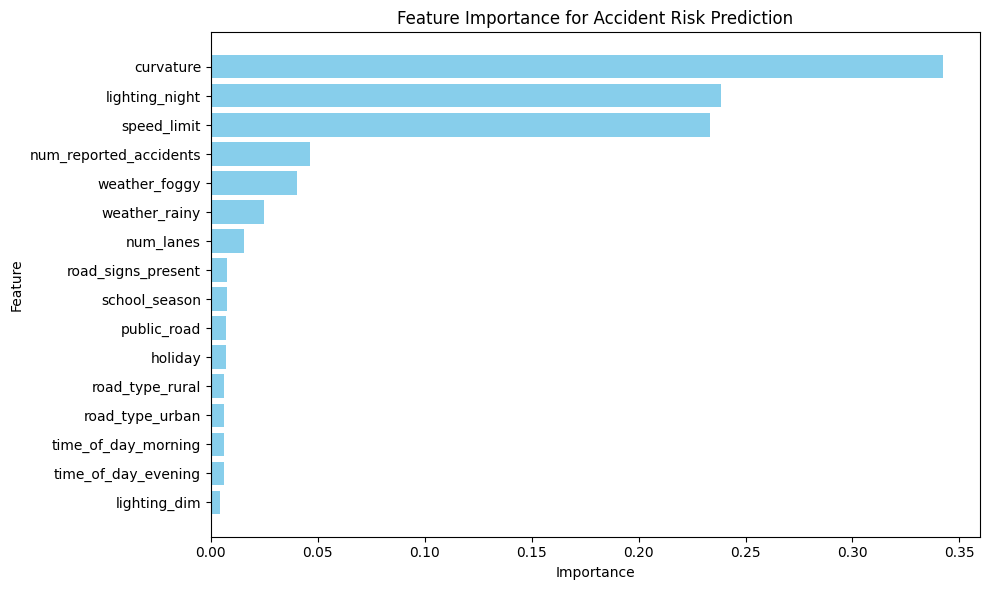

In [30]:
# Create bar plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Accident Risk Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
df_copy['curvature_speed_limit'] = df_copy['curvature'] * df_copy['speed_limit']
df_copy['curvature_lighting_night'] = df_copy['curvature'] * df_copy['lighting_night']
df_copy['speed_limit_foggy'] = df_copy['speed_limit'] * df_copy['weather_foggy']

In [38]:
df_test['curvature_speed_limit'] = df_test['curvature'] * df_test['speed_limit']
df_test['curvature_lighting_night'] = df_test['curvature'] * df_test['lighting_night']
df_test['speed_limit_foggy'] = df_test['speed_limit'] * df_test['weather_foggy']

In [47]:
# Split features and target
X = df_copy.drop('accident_risk', axis=1)
y = df_copy['accident_risk']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

# Display feature importance
print(feature_importance)

                     feature  importance
17  curvature_lighting_night    0.336558
2                speed_limit    0.199886
1                  curvature    0.166811
11            lighting_night    0.067116
16     curvature_speed_limit    0.046470
7     num_reported_accidents    0.046308
13             weather_rainy    0.025761
18         speed_limit_foggy    0.021102
12             weather_foggy    0.017269
0                  num_lanes    0.015354
3         road_signs_present    0.007465
6              school_season    0.007427
4                public_road    0.007121
5                    holiday    0.006868
8            road_type_rural    0.006117
9            road_type_urban    0.006077
15       time_of_day_morning    0.006035
14       time_of_day_evening    0.005913
10              lighting_dim    0.004341


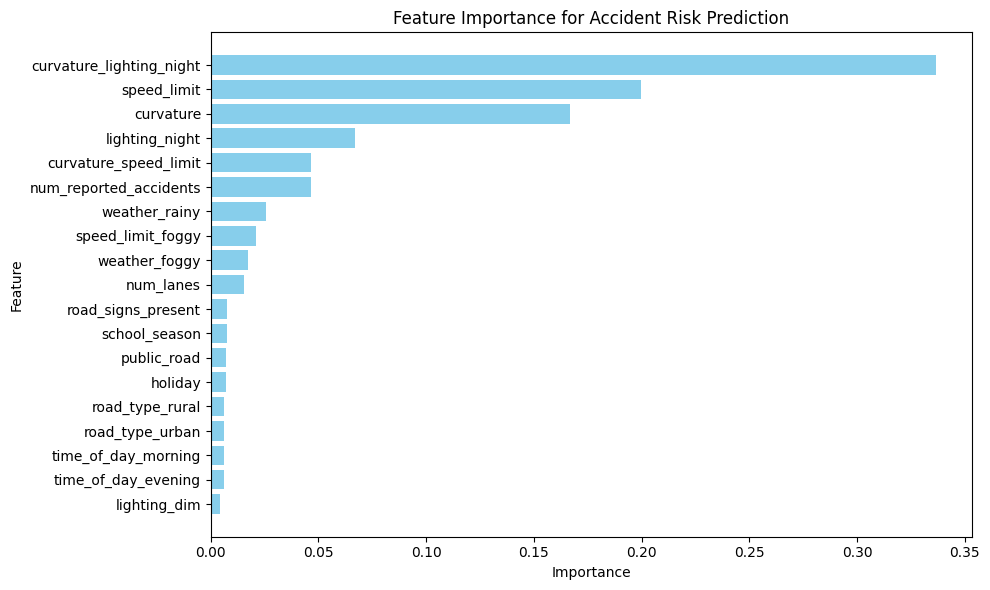

In [39]:
# Create bar plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Accident Risk Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
y_pred = rf.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2_score = r2_score(y_test, y_pred)
rmse, r2_score

(0.05971060256524648, 0.8708774817188452)

In [47]:
# Select top features (importance >0.01)
top_features = [
    'curvature_lighting_night', 'speed_limit', 'curvature', 'lighting_night',
    'curvature_speed_limit', 'num_reported_accidents', 'weather_rainy',
    'speed_limit_foggy', 'weather_foggy'
]
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# Train Random Forest with top features
rf_top = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_top.fit(X_train_top, y_train)

# Evaluate model
y_pred_top = rf_top.predict(X_test_top)
rmse_top = mean_squared_error(y_test, y_pred_top, squared=False)
print(f'RMSE with top features: {rmse_top}')

RMSE with top features: 0.05703149598377611


In [52]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
xgb = XGBRegressor(n_estimators=150, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb, squared=False)
r2_score_xgb = r2_score(y_test, y_pred)
rmse_xgb, r2_score_xgb

(0.0564124441644215, 0.8708774817188452)

In [54]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for GridSearchCV
param_grid = {
    'max_depth': [3, 6, 9],
    'min_child_weight': [1, 3, 5],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 150, 200]
}

# Initialize XGBoost
xgb = XGBRegressor(random_state=42, n_jobs=-1)

# Run GridSearchCV
grid = GridSearchCV(xgb, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

# Best model
best_xgb = grid.best_estimator_
print(f'Best parameters: {grid.best_params_}')
print(f'Best CV RMSE: {(-grid.best_score_)**0.5}')

# Evaluate best model on test set
y_pred_xgb = best_xgb.predict(X_test)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb, squared=False)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f'XGBoost (Best Model) - Test RMSE: {rmse_xgb}, R²: {r2_xgb}')

# Check for overfitting
y_pred_train = best_xgb.predict(X_train)
rmse_train = mean_squared_error(y_train, y_pred_train, squared=False)
print(f'XGBoost (Best Model) - Training RMSE: {rmse_train}')

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 200}
Best CV RMSE: 0.05613125993069534
XGBoost (Best Model) - Test RMSE: 0.056284643243830014, R²: 0.8852694923577845
XGBoost (Best Model) - Training RMSE: 0.05552554575814315


In [48]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
xgb = XGBRegressor(n_estimators=200, learning_rate = 0.1, max_depth = 6, min_child_weight = 5, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb, squared=False)
r2_score_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb, r2_score_xgb

(0.056284643243830014, 0.8852694923577845)

In [54]:
import joblib
joblib.dump(xgb, 'xgbmodel.pkl')

['xgbmodel.pkl']

In [55]:
df_test_id = df_test['id']

KeyError: 'id'

In [45]:
df_test = df_test.drop('id', axis=1)

In [61]:
y_pred_xgb = xgb.predict(df_test)

In [67]:
y_pred_xgb = pd.DataFrame(y_pred_xgb, columns=['accident_risk'])

In [68]:
y_pred = pd.concat([df_test_id, y_pred_xgb], axis=1)

In [62]:
y_pred_xgb

array([0.2889566 , 0.1198082 , 0.19143097, ..., 0.25289887, 0.12892069,
       0.4860958 ], dtype=float32)

In [69]:
y_pred

,id,accident_risk
0,517754,0.288957
1,517755,0.119808
2,517756,0.191431
3,517757,0.331832
4,517758,0.276892
...,...,...
172580,690334,0.107608
172581,690335,0.521630
172582,690336,0.252899
172583,690337,0.128921


In [74]:
y_pred.to_csv('submission.csv', index=False)

In [71]:
y_pred_copy = y_pred.copy()
y_pred_copy

,id,accident_risk
0,517754,0.288957
1,517755,0.119808
2,517756,0.191431
3,517757,0.331832
4,517758,0.276892
...,...,...
172580,690334,0.107608
172581,690335,0.521630
172582,690336,0.252899
172583,690337,0.128921


In [72]:
y_pred_copy['accident_risk'] = y_pred_copy['accident_risk'].round(3)

In [73]:
y_pred_copy

,id,accident_risk
0,517754,0.289
1,517755,0.120
2,517756,0.191
3,517757,0.332
4,517758,0.277
...,...,...
172580,690334,0.108
172581,690335,0.522
172582,690336,0.253
172583,690337,0.129


In [64]:
y_pred

0         517754.288957
1         517755.119808
2         517756.191431
3         517757.331832
4         517758.276892
              ...      
172580    690334.107608
172581    690335.521630
172582    690336.252899
172583    690337.128921
172584    690338.486096
Name: id, Length: 172585, dtype: float64

0         517754
1         517755
2         517756
3         517757
4         517758
           ...  
172580    690334
172581    690335
172582    690336
172583    690337
172584    690338
Name: id, Length: 172585, dtype: int64

# use ANN

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(64, activation='relu', input_shape=(19,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
df_copy

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning,curvature_speed_limit,curvature_lighting_night,speed_limit_foggy
0,-0.438680,-1.572918,-0.703840,0,1,0,1,-0.209797,0.13,0,1,0,0,0,1,0,0,1.107082,-0.000000,-0.000000
1,1.346344,1.839137,-0.703840,1,0,1,1,-1.325918,0.35,0,1,0,0,0,0,1,0,-1.294458,0.000000,-0.000000
2,1.346344,0.518342,1.512963,0,1,1,0,0.906324,0.30,1,0,1,0,0,0,0,1,0.784232,0.000000,0.000000
3,1.346344,-1.536229,-0.703840,1,1,0,0,-0.209797,0.21,0,0,1,0,0,1,0,1,1.081259,-0.000000,-0.000000
4,-1.331192,0.334898,0.879591,0,0,1,0,-0.209797,0.56,1,0,0,0,1,0,1,0,0.294573,0.000000,0.879591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,1.346344,-1.426163,1.512963,1,1,0,0,0.906324,0.32,0,0,0,0,1,0,0,0,-2.157732,-0.000000,1.512963
517750,1.346344,-0.068678,-0.703840,1,1,0,0,-0.209797,0.26,1,0,0,0,0,1,0,1,0.048339,-0.000000,-0.000000
517751,1.346344,0.481653,-1.337212,0,0,0,1,-1.325918,0.19,0,1,0,0,1,0,0,0,-0.644072,0.000000,-1.337212
517752,0.453832,0.518342,-1.337212,1,0,1,1,2.022445,0.51,0,0,0,1,0,0,0,0,-0.693133,0.518342,-0.000000


In [27]:
# Split features and target
X = df_copy.drop('accident_risk', axis=1)
y = df_copy['accident_risk']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), 
                    epochs=50, batch_size=32, verbose=1)

# Evaluate
y_pred_ann = model.predict(X_test).flatten()
rmse_ann = mean_squared_error(y_test, y_pred_ann, squared=False)
r2_ann = r2_score(y_test, y_pred_ann)
print(f'ANN - Test RMSE: {rmse_ann}, R²: {r2_ann}')

# Check for overfitting
y_pred_train = model.predict(X_train).flatten()
rmse_train = mean_squared_error(y_train, y_pred_train, squared=False)
print(f'ANN - Training RMSE: {rmse_train}')

Epoch 1/50


I0000 00:00:1760800524.313586      95 service.cc:148] XLA service 0x7daef410b580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760800524.314185      95 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1760800524.557325      95 cuda_dnn.cc:529] Loaded cuDNN version 90300


   74/12944 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 0.0405 - mae: 0.1570

I0000 00:00:1760800525.892630      95 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12944/12944 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 0.0067 - mae: 0.0620 - val_loss: 0.0034 - val_mae: 0.0451
Epoch 2/50
12944/12944 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.0039 - mae: 0.0488 - val_loss: 0.0034 - val_mae: 0.0455
Epoch 3/50
12944/12944 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.0039 - mae: 0.0484 - val_loss: 0.0033 - val_mae: 0.0446
Epoch 4/50
12944/12944 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.0038 - mae: 0.0480 - val_loss: 0.0033 - val_mae: 0.0447
Epoch 5/50
12944/12944 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.0038 - mae: 0.0478 - val_loss: 0.0034 - val_mae: 0.0450
Epoch 6/50
12944/12944 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.0038 - mae: 0.0478 - val_loss: 0.0034 - val_mae: 0.0452
Epoch 7/50
12944/12944 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.0038 - mae: 0.0477 - val_loss: 0.0033 - val_mae: 0.0446
Epoch 8/50
12944/12944 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.0038 - mae: 0.0477 - val_loss: 0.0033 - val_mae: 0.0444
Epoch 9/50
12944/12944 ━━━━

KeyboardInterrupt: 